In [1]:
# import libraries

from urllib import request
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

from sqlalchemy import create_engine
from scipy.stats import normaltest

import os


# Create folder for saving charts
os.makedirs("charts", exist_ok=True)

In [2]:
# mysql connection

from urllib.parse import quote_plus
from dotenv import load_dotenv

load_dotenv()

MYSQL_USER = "root"
MYSQL_PASSWORD = quote_plus(os.getenv("password"))
MYSQL_HOST = "localhost"
MYSQL_PORT = "3306"
MYSQL_DATABASE = "eda_weather_db"

try:
    # Create SQLAlchemy engine
    engine = create_engine(
        f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
    )

    with engine.connect() as connection:
        print("Successfully connected to MySQL database.")

except Exception as e:
    print("\nCould not connect to MySQL server, ", e)

Successfully connected to MySQL database.


In [3]:
# create database if not exists

connection = pymysql.connect(
    host="localhost",
    user="root",
    password=os.getenv("password")
)

cursor = connection.cursor()

cursor.execute("CREATE DATABASE IF NOT EXISTS eda_weather_db")

connection.commit()

cursor.close()
connection.close()

print("Database created successfully.")

Database created successfully.


In [4]:
# define cities

cities = {
    "Kathmandu": (27.7172, 85.3240),
    "London": (51.5072, -0.1276),
    "Tokyo": (35.6762, 139.6503),
    "New York": (40.7128, -74.0060),
    "Sydney": (-33.8688, 151.2093)
}

cities

{'Kathmandu': (27.7172, 85.324),
 'London': (51.5072, -0.1276),
 'Tokyo': (35.6762, 139.6503),
 'New York': (40.7128, -74.006),
 'Sydney': (-33.8688, 151.2093)}

In [5]:
# fetch weather data

all_weather_data = []

for city, (lat, lon) in cities.items():

    url = (
        f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={lat}&longitude={lon}"
        f"&daily=temperature_2m_max,temperature_2m_min"
        f"&forecast_days=7"
        f"&timezone=auto"
    )

    try:
        # Open URL
        response = request.urlopen(url, timeout = 10)

        # Read JSON response
        data = json.loads(response.read().decode("utf-8"))

        # Extract daily weather data
        daily = data["daily"]

        # Create DataFrame
        temp_df = pd.DataFrame({
            "city": city,
            "date": daily["time"],
            "max_temp": daily["temperature_2m_max"],
            "min_temp": daily["temperature_2m_min"]
        })

        all_weather_data.append(temp_df)

        print(f"{city} data fetched successfully.")

    except Exception as e:
        print(f"Error fetching data for {city}: {e}")

Kathmandu data fetched successfully.
London data fetched successfully.
Tokyo data fetched successfully.
New York data fetched successfully.
Sydney data fetched successfully.


In [6]:
# combine all data

weather_df = pd.concat(all_weather_data, ignore_index=True)

weather_df.head()

,city,date,max_temp,min_temp
0,Kathmandu,2026-05-21,26.0,19.3
1,Kathmandu,2026-05-22,25.2,18.1
2,Kathmandu,2026-05-23,27.1,18.5
3,Kathmandu,2026-05-24,28.2,17.6
4,Kathmandu,2026-05-25,27.8,17.8


In [7]:
# store and load data from mysql

weather_df.to_sql(
    name="eda_weather_db",
    con=engine,
    if_exists="replace",
    index=False
)

print("Data stored into MySQL successfully.\n")

#load form mysql
df = pd.read_sql("SELECT * FROM eda_weather_db", engine)

df.head()

Data stored into MySQL successfully.



,city,date,max_temp,min_temp
0,Kathmandu,2026-05-21,26.0,19.3
1,Kathmandu,2026-05-22,25.2,18.1
2,Kathmandu,2026-05-23,27.1,18.5
3,Kathmandu,2026-05-24,28.2,17.6
4,Kathmandu,2026-05-25,27.8,17.8


In [8]:
# basic eda

print("Shape of Data:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

print("\nCity Counts:")
print(df["city"].value_counts())

Shape of Data:
(35, 4)

Column Names:
Index(['city', 'date', 'max_temp', 'min_temp'], dtype='object')

Missing Values:
city        0
date        0
max_temp    0
min_temp    0
dtype: int64

Descriptive Statistics:
        max_temp   min_temp
count  35.000000  35.000000
mean   23.111429  15.451429
std     5.299821   3.234681
min    12.900000  10.500000
25%    19.600000  13.050000
50%    23.100000  15.600000
75%    27.100000  17.850000
max    34.300000  23.100000

City Counts:
city
Kathmandu    7
London       7
Tokyo        7
New York     7
Sydney       7
Name: count, dtype: int64


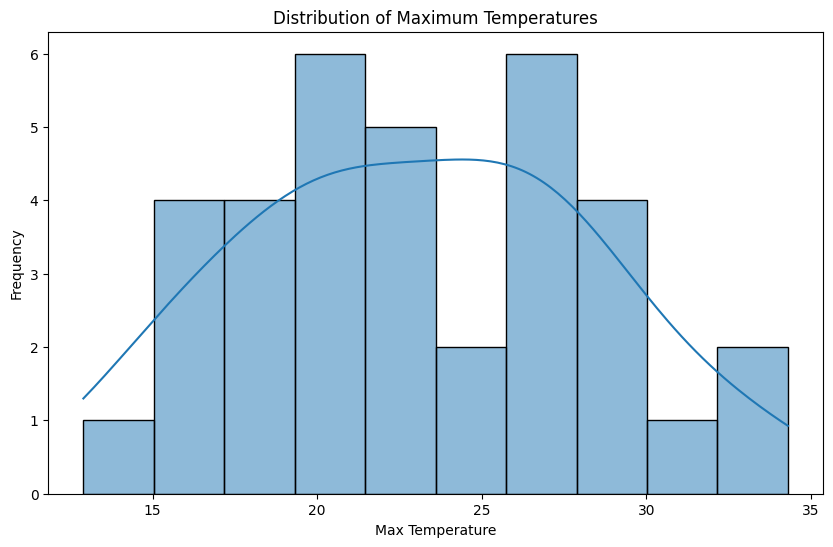

In [9]:
# histogram of max temperature

plt.figure(figsize=(10,6))

sns.histplot(df["max_temp"], bins=10, kde=True)

plt.title("Distribution of Maximum Temperatures")
plt.xlabel("Max Temperature")
plt.ylabel("Frequency")

plt.savefig("charts/histogram_max_temp.png")

plt.show()

In [10]:
# normal distribution test

stat, p_value = normaltest(df["max_temp"])

print("P-value:", p_value)

if p_value > 0.05:
    print("Data appears normally distributed.")
else:
    print("Data is NOT normally distributed.")

P-value: 0.6403819112682662
Data appears normally distributed.


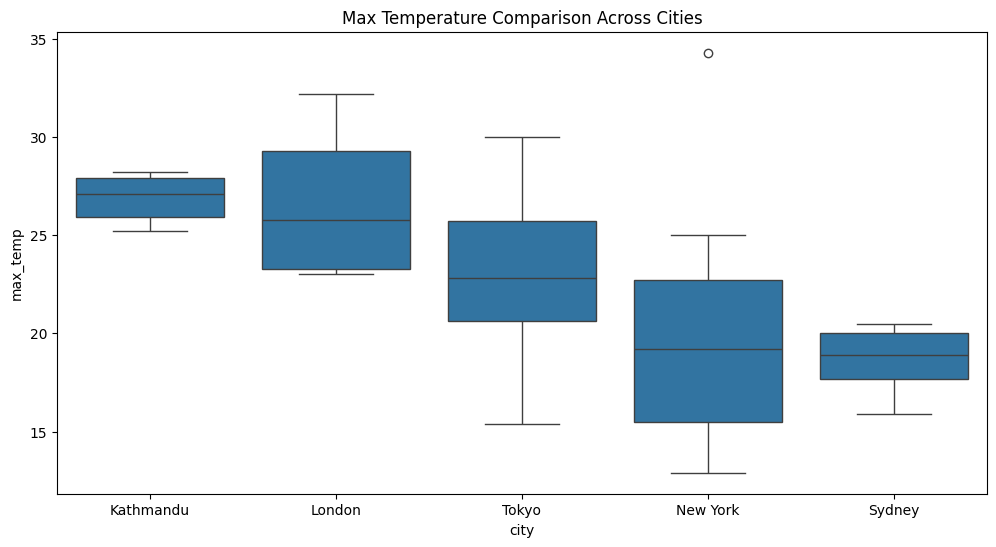

In [11]:
# boxplot comparision

plt.figure(figsize=(12,6))

sns.boxplot(x="city", y="max_temp", data=df)

plt.title("Max Temperature Comparison Across Cities")

plt.savefig("charts/boxplot_cities.png")

plt.show()

In [12]:
# detect outliers using iqr

Q1 = df["max_temp"].quantile(0.25)
Q3 = df["max_temp"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["max_temp"] < lower_bound) |
    (df["max_temp"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nOutliers:")
print(outliers)

Lower Bound: 8.350000000000001
Upper Bound: 38.35

Outliers:
Empty DataFrame
Columns: [city, date, max_temp, min_temp]
Index: []


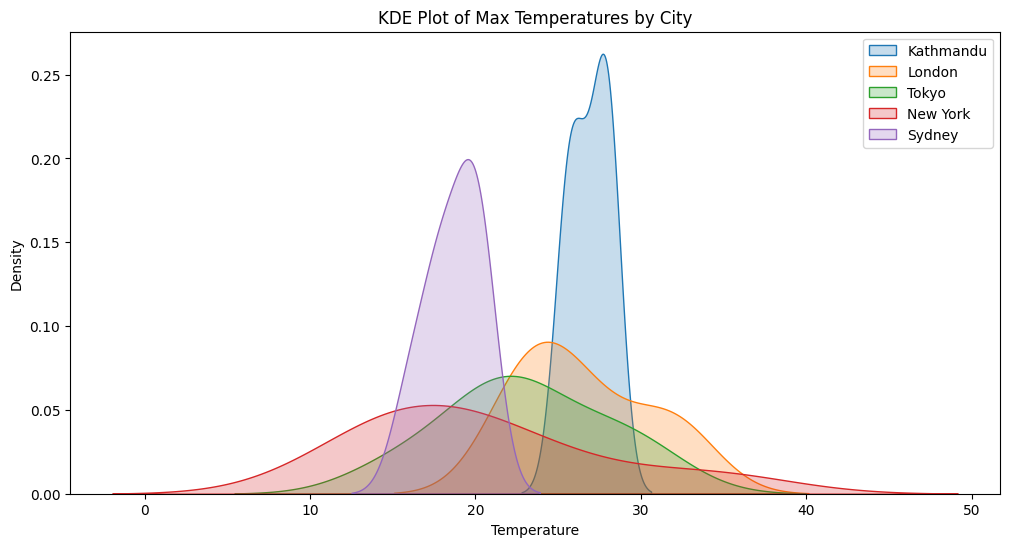

In [13]:
# kde plot for all cities

plt.figure(figsize=(12,6))

for city in df["city"].unique():

    city_data = df[df["city"] == city]

    sns.kdeplot(
        city_data["max_temp"],
        label=city,
        fill=True
    )

plt.title("KDE Plot of Max Temperatures by City")

plt.xlabel("Temperature")
plt.ylabel("Density")

plt.legend()

plt.savefig("charts/kde_plot.png")

plt.show()

In [14]:
# summary staatistics table

summary = df.groupby("city")["max_temp"].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
])

summary

,mean,median,std,min,max
city,,,,,
Kathmandu,26.885714,27.1,1.186632,25.2,28.2
London,26.600000,25.8,3.896152,23.0,32.2
New York,20.400000,19.2,7.303880,12.9,34.3
Sydney,18.671429,18.9,1.667048,15.9,20.5
Tokyo,23.000000,22.8,4.903400,15.4,30.0


In [15]:
# find city wwith widest temperature spread

spread = df.groupby("city")["max_temp"].std()

widest_spread_city = spread.idxmax()

print("City with widest spread:")
print(widest_spread_city)

City with widest spread:
New York


In [16]:
# observations

observations = [
    "1. Some cities have much higher temperature variability than others.",
    
    "2. KDE plots show overlapping temperature distributions across cities.",
    
    "3. Boxplots reveal possible outliers in extreme weather days.",
    
    "4. Histogram indicates whether combined temperatures follow normal distribution.",
    
    "5. Cities with high standard deviation have the widest temperature spread."
]

for obs in observations:
    print(obs)

1. Some cities have much higher temperature variability than others.
2. KDE plots show overlapping temperature distributions across cities.
3. Boxplots reveal possible outliers in extreme weather days.
4. Histogram indicates whether combined temperatures follow normal distribution.
5. Cities with high standard deviation have the widest temperature spread.


In [17]:
# verify saved charts

files = [
    "histogram_max_temp.png",
    "boxplot_cities.png",
    "kde_plot.png"
]

for file in files:
    print(file, "Exists" if os.path.exists(file) else "Missing")

histogram_max_temp.png Missing
boxplot_cities.png Missing
kde_plot.png Missing
